In [5]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load CSV from URL
url = 'muwi/streets_beat.csv'
df = pd.read_csv(url)

# Step 3: Display the first few rows of the DataFrame
display(df)


,TIME,LABEL
0,0.748844,NaN
1,1.010068,NaN
2,1.123265,NaN
3,1.432381,NaN
4,2.133333,NaN
...,...,...
90,30.344490,NaN
91,31.030204,NaN
92,31.291429,NaN
93,31.431837,NaN


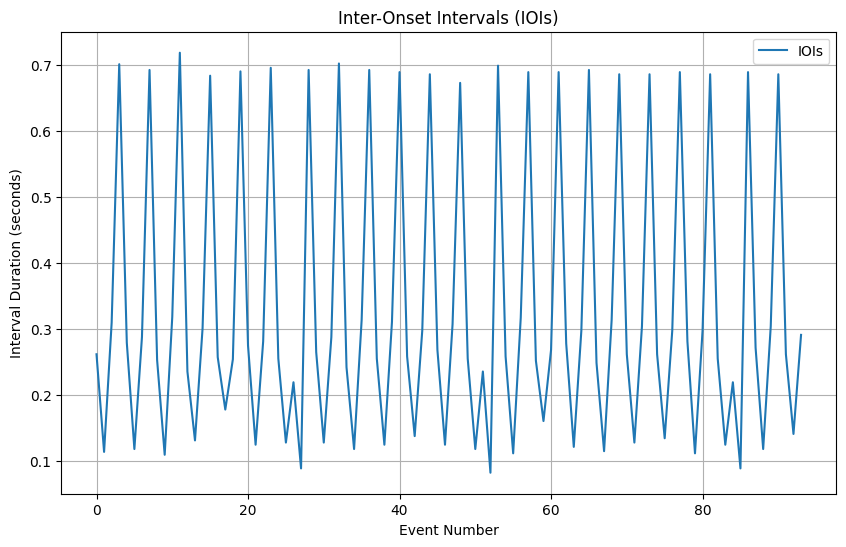

Mean IOI (Average Interval Duration): 0.3295064408829787
Standard Deviation of IOIs: 0.21096186642993164
Coefficient of Variation of IOIs: 0.6402359415634393


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Onset times in seconds
onset_times = df['TIME'].values

# Calculate inter-onset intervals (IOIs)
iois = np.diff(onset_times)

# Plot the IOIs
plt.figure(figsize=(10, 6))
plt.plot(iois, label="IOIs")
plt.title('Inter-Onset Intervals (IOIs)')
plt.xlabel('Event Number')
plt.ylabel('Interval Duration (seconds)')
plt.grid(True)
plt.legend()
plt.show()

# Calculate standard deviation and coefficient of variation
mean_ioi = np.mean(iois)
std_ioi = np.std(iois)
cv_ioi = std_ioi / mean_ioi  # Coefficient of variation

# Print out results with descriptions
print("Mean IOI (Average Interval Duration):", mean_ioi)
print("Standard Deviation of IOIs:", std_ioi)
print("Coefficient of Variation of IOIs:", cv_ioi)


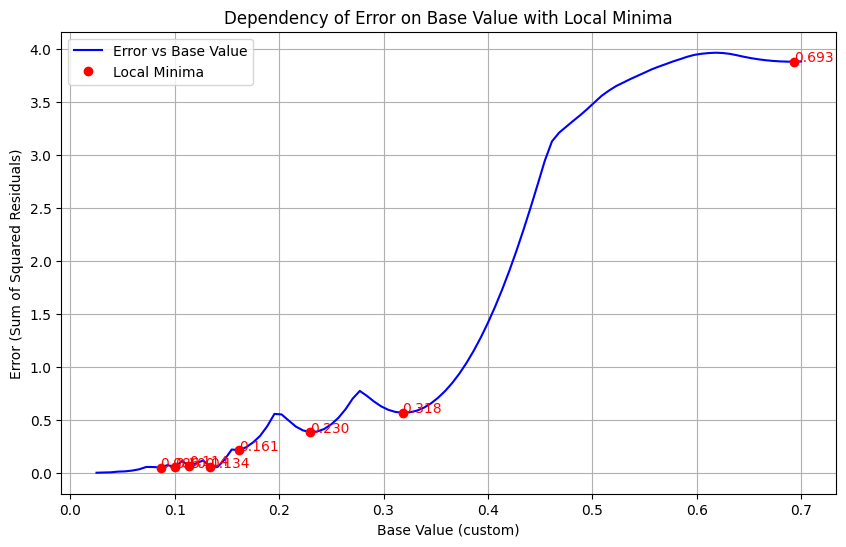

Local minima (base values) and corresponding errors:
Base Value: 0.08636, Error: 0.05499
Base Value: 0.10000, Error: 0.05991
Base Value: 0.11364, Error: 0.07255
Base Value: 0.13409, Error: 0.05768
Base Value: 0.16136, Error: 0.21902
Base Value: 0.22955, Error: 0.38924
Base Value: 0.31818, Error: 0.57157
Base Value: 0.69318, Error: 3.88172


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Example data (replace with actual data)
data = iois

# Define a range of base values to explore
base_values = np.linspace(0.025, 0.7, 100)  # Adjust range if needed

# Initialize an empty list to store the errors
errors = []

# Loop through different base values and compute the error for each
for base_value_custom in base_values:
    # Calculate multipliers and reconstructed data
    multipliers = np.round(data / base_value_custom)
    reconstructed_data = base_value_custom * multipliers

    # Calculate the residuals and error (sum of squared residuals)
    residuals = data - reconstructed_data
    error = np.sum(residuals**2)

    # Append the error to the list
    errors.append(error)

# Convert errors to a numpy array for further processing
errors = np.array(errors)

# Find local minima (by finding peaks of the negative error array)
minima_indices, _ = find_peaks(-errors)

# Plotting the dependency of the error on the base_value_custom
plt.figure(figsize=(10, 6))
plt.plot(base_values, errors, label='Error vs Base Value', color='blue')

# Mark the local minima
plt.plot(base_values[minima_indices], errors[minima_indices], 'ro', label='Local Minima')

# Annotate the local minima on the plot
for idx in minima_indices:
    plt.text(base_values[idx], errors[idx], f'{base_values[idx]:.3f}', color='red')

plt.title('Dependency of Error on Base Value with Local Minima')
plt.xlabel('Base Value (custom)')
plt.ylabel('Error (Sum of Squared Residuals)')
plt.grid(True)
plt.legend()
plt.show()

# Print out the local minima values
print("Local minima (base values) and corresponding errors:")
for idx in minima_indices:
    print(f"Base Value: {base_values[idx]:.5f}, Error: {errors[idx]:.5f}")


Error (sum of squared residuals): 0.3889102038310215


,Original IOI,Multiplier,Reconstructed IOI,Residual
0,0.261224,1.0,0.23,0.031224
1,0.113197,0.0,0.00,0.113197
2,0.309116,1.0,0.23,0.079116
3,0.700952,3.0,0.69,0.010952
4,0.278639,1.0,0.23,0.048639
...,...,...,...,...
89,0.303673,1.0,0.23,0.073673
90,0.685714,3.0,0.69,-0.004286
91,0.261224,1.0,0.23,0.031224
92,0.140408,1.0,0.23,-0.089592


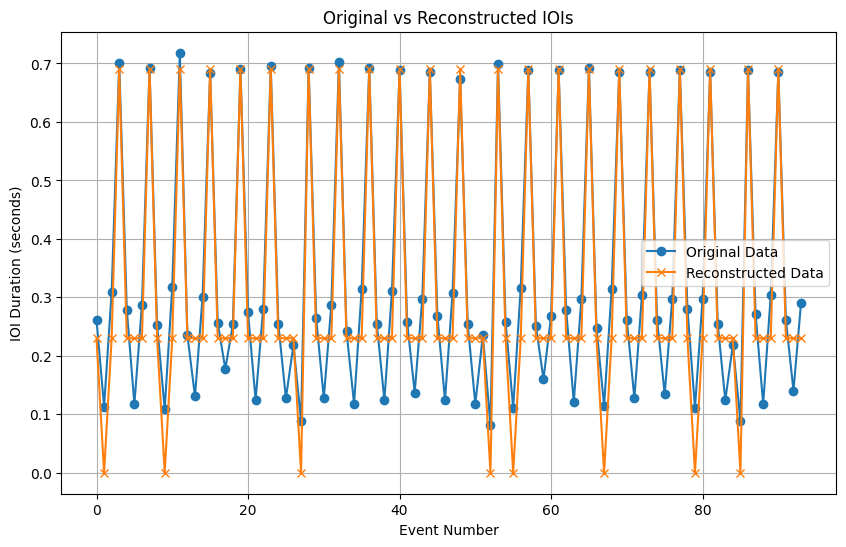

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example data (replace with actual data)
data = iois

# Custom base value (input your desired base value here)
base_value_custom = 0.230  # Adjust this value as needed

# Calculate multipliers and reconstructed data
multipliers = np.round(data / base_value_custom)
reconstructed_data = base_value_custom * multipliers

# Error calculation (Sum of squared residuals)
residuals = data - reconstructed_data
error = np.sum(residuals**2)

print(f"Error (sum of squared residuals): {error}")

# Create a DataFrame with Original IOI, Multiplier, Reconstructed IOI, Residual
df_results = pd.DataFrame({
    'Original IOI': data,
    'Multiplier': multipliers,
    'Reconstructed IOI': reconstructed_data,
    'Residual': residuals
})

# Display the DataFrame in Colab
display(df_results)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(data, label='Original Data', marker='o')
plt.plot(reconstructed_data, label='Reconstructed Data', marker='x')
plt.legend()
plt.title('Original vs Reconstructed IOIs')
plt.xlabel('Event Number')
plt.ylabel('IOI Duration (seconds)')
plt.grid(True)
plt.show()
